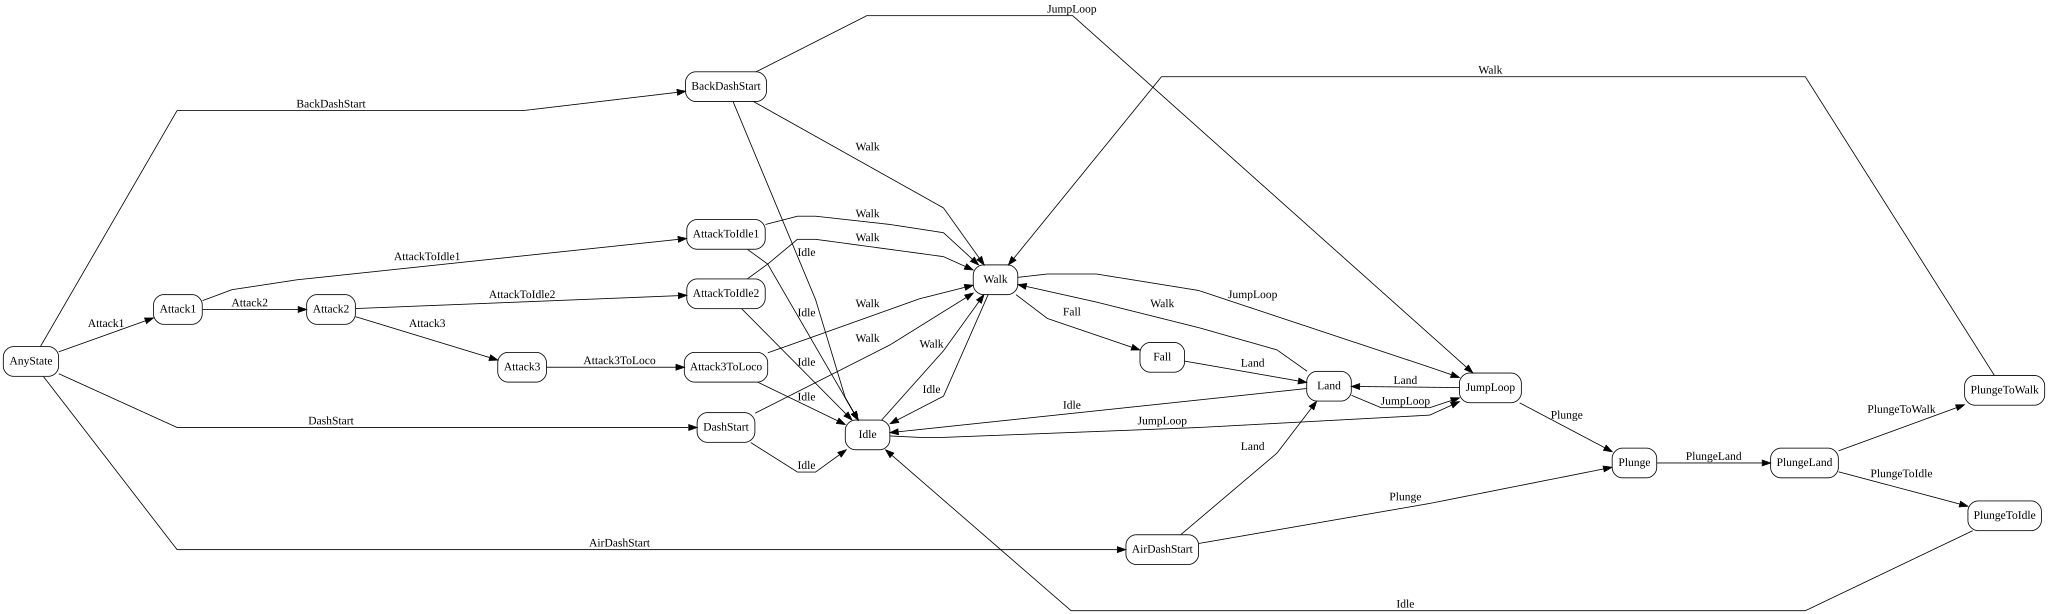

In [1]:
import json
from graphviz import Digraph
from IPython.display import SVG, display

def visualize_fsm(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Use 'sfdp' or 'dot' engine. 'dot' is usually best for state machines.
    dot = Digraph(engine='dot', format='svg')

    # --- CRITICAL LAYOUT SETTINGS ---
    dot.attr(rankdir='LR')           # Left to Right flow
    dot.attr(overlap='false')        # Don't let nodes touch
    dot.attr(splines='polyline')     # Straight lines are often easier to read than huge curves
    dot.attr(nodesep='0.5')          # Space between nodes
    dot.attr(ranksep='1.0')          # Space between "layers" of states
    dot.attr(fontname='Arial')

    state_map = data.get("stateMap", {})
    
    for state_name, state_data in state_map.items():
        # Make states smaller so they don't push the graph off-screen
        dot.node(state_name, state_name, shape='rectangle', style='rounded,filled', fillcolor='white')

        for trans in state_data.get("transitions", []):
            target = trans.get("targetState")
            # Get the first condition as a label
            label = trans['conditions'][0]['paramName'] if trans.get('conditions') else ""
            dot.edge(state_name, target, label=label)

    # Save and Display
    dot.render('game_fsm_output', cleanup=True)
    display(SVG(filename='game_fsm_output.svg'))

visualize_fsm("Slice/SliceEditor/Assets/Default/DefaultController.controller")